# Grammar parameter sweep: k, alphabet size, forbidden fraction

`config/evaluation/case_sets/2g_2b_all.yaml` currently varies `alphabet_size`, `k`, and
`forbidden_fraction` per tier (alongside `dimensions`, `board_depth`). That is a lot of simultaneously-varying axes. This notebook
checks two things, using `src/formal/grammar/analysis.py`:

1. **Are `alphabet_size` and `forbidden_fraction` redundant difficulty knobs?**
   In `sample_sl_grammar`, every k-gram is forbidden independently with probability
   `forbidden_fraction`, so the expected out-degree of every de Bruijn node — and hence
   the Perron eigenvalue λ (the language's growth rate / branching factor) — is
   roughly `alphabet_size * (1 - forbidden_fraction)`, largely independent of `k`.

3. **How far can `k` go?** `k` controls the de Bruijn state space
   (`alphabet_size ** (k - 1)`), and `StrictlyLocalLanguage.to_dfa()` additionally needs
   `min_word_length >= k - 1` to terminate (otherwise the warm-up phase never reaches
   `k - 1` symbols of history and the history string grows without bound).

Goal: pick a fixed `(k, alphabet_size)` to keep constant across tiers, and use
`forbidden_fraction` as the main difficulty axis.

In [1]:
import time
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.formal.grammar.alphabet import LetterAlphabetSampler
from src.formal.grammar.analysis import perron_eigenvalue, word_count_spectrum
from src.formal.grammar.sampler import sample_sl_grammar

SEED = 42

## 1. State-space size and `k` feasibility

The de Bruijn graph (and the dense matrix `perron_eigenvalue` builds) has
`alphabet_size ** (k - 1)` nodes. The current `evaluation_base_grammar` grammar config fixes
`min_word_length = 3`, which only satisfies `min_word_length >= k - 1` for `k <= 4`.
For `k = 5` we'd need `min_word_length = 4`.

In [2]:
ALPHABET_SIZES = [4, 5, 6, 7, 8, 9, 10]
KS = [2, 3, 4, 5]

state_space = pd.DataFrame(
    {k: [a ** (k - 1) for a in ALPHABET_SIZES] for k in KS},
    index=ALPHABET_SIZES,
)
state_space.index.name = "alphabet_size"
state_space.columns.name = "k (state space = alphabet_size ** (k-1))"
state_space

k (state space = alphabet_size ** (k-1)),2,3,4,5
alphabet_size,,,,
4,4,16,64,256
5,5,25,125,625
6,6,36,216,1296
7,7,49,343,2401
8,8,64,512,4096
9,9,81,729,6561
10,10,100,1000,10000


In [3]:
# to_dfa() feasibility: needs min_word_length >= k - 1 to terminate.
dfa_rows = []
for k in KS:
    min_wl = max(3, k - 1)
    for alphabet_size in [4, 6, 8, 10]:
        alphabet = LetterAlphabetSampler().sample(alphabet_size, SEED)
        grammar = sample_sl_grammar(
            alphabet=alphabet,
            k=k,
            forbidden_fraction=0.3,
            min_word_length=min_wl,
            seed=SEED,
        )
        start = time.perf_counter()
        dfa = grammar.to_dfa()
        elapsed = time.perf_counter() - start
        dfa_rows.append(
            {
                "k": k,
                "alphabet_size": alphabet_size,
                "min_word_length": min_wl,
                "dfa_states": len(dfa.states),
                "to_dfa_seconds": elapsed,
            }
        )

pd.DataFrame(dfa_rows)

,k,alphabet_size,min_word_length,dfa_states,to_dfa_seconds
0,2,4,3,14,0.000060
1,2,6,3,20,0.000060
2,2,8,3,26,0.000083
3,2,10,3,32,0.000119
4,3,4,3,37,0.000113
5,3,6,3,80,0.000252
6,3,8,3,138,0.000655
7,3,10,3,212,0.001727
8,4,4,3,86,0.000423
9,4,6,3,260,0.000801


`to_dfa()` itself stays cheap even at `k=5` (a few thousand states, well under a
second). The real cost at `k=5` is `perron_eigenvalue`, which diagonalizes a dense
`alphabet_size**4 x alphabet_size**4` matrix and is also called repeatedly during
`auto_resample`. Timing it directly:

In [4]:
# perron_eigenvalue cost at k=5 (dense matrix is alphabet_size**4 x alphabet_size**4).
for alphabet_size in [4, 5, 6, 7, 8]:
    alphabet = LetterAlphabetSampler().sample(alphabet_size, SEED)
    grammar = sample_sl_grammar(
        alphabet=alphabet, k=5, forbidden_fraction=0.3, min_word_length=4, seed=SEED,
    )
    start = time.perf_counter()
    lam = perron_eigenvalue(grammar)
    elapsed = time.perf_counter() - start
    print(f"k=5 |Σ|={alphabet_size} (n={alphabet_size**4:5d}) -> "
          f"lambda={lam:.3f}  time={elapsed:.3f}s")

k=5 |Σ|=4 (n=  256) -> lambda=2.817  time=0.025s
k=5 |Σ|=5 (n=  625) -> lambda=3.530  time=0.114s
k=5 |Σ|=6 (n= 1296) -> lambda=4.234  time=0.442s
k=5 |Σ|=7 (n= 2401) -> lambda=4.930  time=3.218s
k=5 |Σ|=8 (n= 4096) -> lambda=5.605  time=22.112s


## 2. Does λ depend only on `alphabet_size` and `forbidden_fraction` — not `k`?

For each `(alphabet_size, k, forbidden_fraction)` combination, sample several grammars
with `sample_sl_grammar` (no auto-resample, so the raw effect of `forbidden_fraction` is
visible) and compute the Perron eigenvalue λ. `lambda_theory` is
`alphabet_size * (1 - forbidden_fraction)`, the expected out-degree of every de Bruijn
node.

`k = 5` is excluded from this sweep (the larger alphabet sizes get too slow per the
timing above); `k <= 4` already covers the range used by `2g_2b_all.yaml`.

In [5]:
ALPHABET_SIZES_SWEEP = [4, 6, 8, 10]
KS_SWEEP = [2, 3, 4]
FORBIDDEN_FRACTIONS = [0.1, 0.2, 0.3, 0.4, 0.5]
N_SEEDS = 5
MIN_WORD_LENGTH = 3

rows = []
for alphabet_size, k, forbidden_fraction in product(
    ALPHABET_SIZES_SWEEP, KS_SWEEP, FORBIDDEN_FRACTIONS
):
    alphabet = LetterAlphabetSampler().sample(alphabet_size, SEED)
    lambdas = [
        perron_eigenvalue(
            sample_sl_grammar(
                alphabet=alphabet,
                k=k,
                forbidden_fraction=forbidden_fraction,
                min_word_length=MIN_WORD_LENGTH,
                seed=SEED + seed_offset,
            )
        )
        for seed_offset in range(N_SEEDS)
    ]
    rows.append(
        {
            "alphabet_size": alphabet_size,
            "k": k,
            "forbidden_fraction": forbidden_fraction,
            "lambda_mean": np.mean(lambdas),
            "lambda_std": np.std(lambdas),
            "lambda_theory": alphabet_size * (1 - forbidden_fraction),
        }
    )

sweep = pd.DataFrame(rows)
sweep

,alphabet_size,k,forbidden_fraction,lambda_mean,lambda_std,lambda_theory
0,4,2,0.1,3.323383,0.239043,3.6
1,4,2,0.2,2.758081,0.269055,3.2
2,4,2,0.3,2.249376,0.692919,2.8
3,4,2,0.4,1.917143,0.678834,2.4
4,4,2,0.5,1.653663,0.449337,2.0
5,4,3,0.1,3.435062,0.089175,3.6
6,4,3,0.2,2.977451,0.117896,3.2
7,4,3,0.3,2.656494,0.234174,2.8
8,4,3,0.4,2.256442,0.262517,2.4
9,4,3,0.5,2.025830,0.157802,2.0


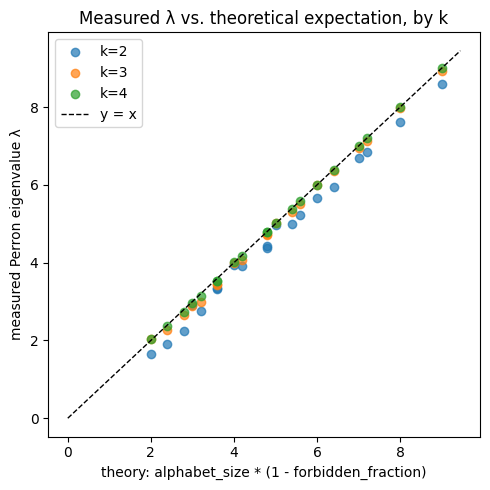

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
for k in KS_SWEEP:
    subset = sweep[sweep["k"] == k]
    ax.scatter(subset["lambda_theory"], subset["lambda_mean"], label=f"k={k}", alpha=0.7)

lims = [0, sweep["lambda_theory"].max() * 1.05]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1, label="y = x")
ax.set_xlabel("theory: alphabet_size * (1 - forbidden_fraction)")
ax.set_ylabel("measured Perron eigenvalue λ")
ax.set_title("Measured λ vs. theoretical expectation, by k")
ax.legend()
fig.tight_layout()

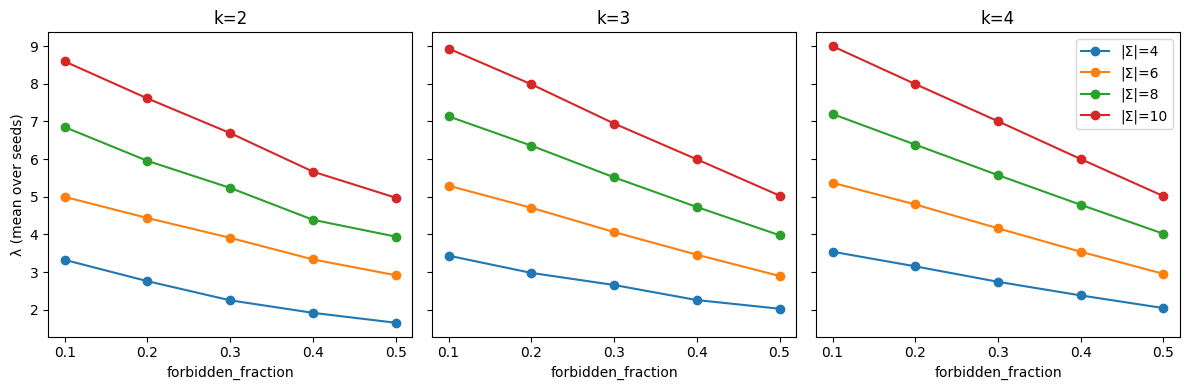

In [7]:
fig, axes = plt.subplots(1, len(KS_SWEEP), figsize=(4 * len(KS_SWEEP), 4), sharey=True)
for ax, k in zip(axes, KS_SWEEP):
    for alphabet_size in ALPHABET_SIZES_SWEEP:
        subset = sweep[(sweep["k"] == k) & (sweep["alphabet_size"] == alphabet_size)]
        ax.plot(
            subset["forbidden_fraction"],
            subset["lambda_mean"],
            marker="o",
            label=f"|Σ|={alphabet_size}",
        )
    ax.set_title(f"k={k}")
    ax.set_xlabel("forbidden_fraction")
axes[0].set_ylabel("λ (mean over seeds)")
axes[-1].legend()
fig.tight_layout()

## 3. Word counts: avoiding degenerate or near-unconstrained languages

`word_count_spectrum` also depends on `min_word_length`: the warm-up phase only checks
forbidden k-grams once `phase >= k - 1`, so we use
`min_word_length = max(3, k - 1)` here (matching what `to_dfa()` needs) so the counts
reflect the language that's actually enforced during generation.

In [8]:
WORD_LENGTH = 8

word_rows = []
for alphabet_size, k, forbidden_fraction in product(
    ALPHABET_SIZES_SWEEP, KS_SWEEP, FORBIDDEN_FRACTIONS
):
    alphabet = LetterAlphabetSampler().sample(alphabet_size, SEED)
    counts = [
        word_count_spectrum(
            sample_sl_grammar(
                alphabet=alphabet,
                k=k,
                forbidden_fraction=forbidden_fraction,
                min_word_length=max(3, k - 1),
                seed=SEED + seed_offset,
            ),
            WORD_LENGTH,
        )[WORD_LENGTH]
        for seed_offset in range(N_SEEDS)
    ]
    word_rows.append(
        {
            "alphabet_size": alphabet_size,
            "k": k,
            "forbidden_fraction": forbidden_fraction,
            "word_count_mean": np.mean(counts),
            "max_possible": alphabet_size ** WORD_LENGTH,
        }
    )

words = pd.DataFrame(word_rows)
words["fraction_of_max"] = words["word_count_mean"] / words["max_possible"]
words

,alphabet_size,k,forbidden_fraction,word_count_mean,max_possible,fraction_of_max
0,4,2,0.1,19714.4,65536,0.300818
1,4,2,0.2,6152.4,65536,0.093878
2,4,2,0.3,3906.8,65536,0.059613
3,4,2,0.4,1889.4,65536,0.028830
4,4,2,0.5,457.2,65536,0.006976
5,4,3,0.1,26423.8,65536,0.403195
6,4,3,0.2,11459.8,65536,0.174863
7,4,3,0.3,6371.2,65536,0.097217
8,4,3,0.4,2645.6,65536,0.040369
9,4,3,0.5,1248.4,65536,0.019049


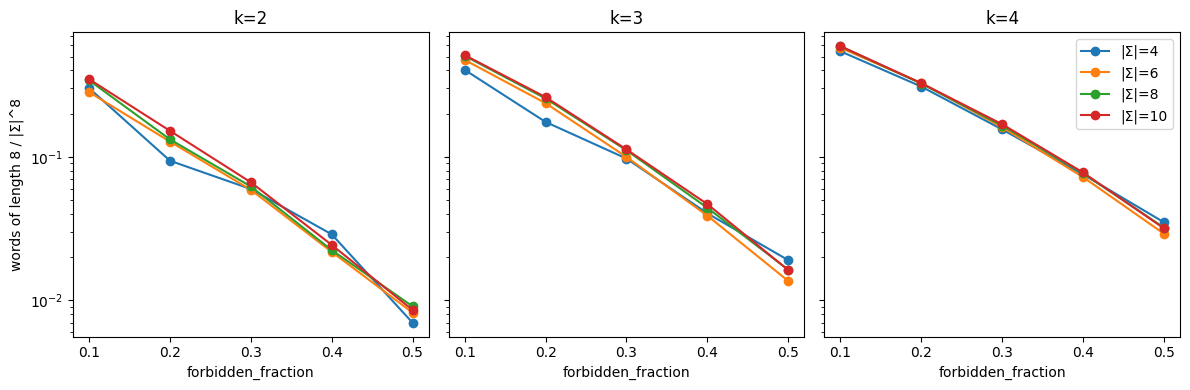

In [9]:
fig, axes = plt.subplots(1, len(KS_SWEEP), figsize=(4 * len(KS_SWEEP), 4), sharey=True)
for ax, k in zip(axes, KS_SWEEP):
    for alphabet_size in ALPHABET_SIZES_SWEEP:
        subset = words[(words["k"] == k) & (words["alphabet_size"] == alphabet_size)]
        ax.plot(
            subset["forbidden_fraction"],
            subset["fraction_of_max"],
            marker="o",
            label=f"|Σ|={alphabet_size}",
        )
    ax.set_title(f"k={k}")
    ax.set_xlabel("forbidden_fraction")
    ax.set_yscale("log")
axes[0].set_ylabel(f"words of length {WORD_LENGTH} / |Σ|^{WORD_LENGTH}")
axes[-1].legend()
fig.tight_layout()

## 4. Candidate fixed `(k, alphabet_size)` combos

Pick a few candidates and read off the λ range as `forbidden_fraction` sweeps the
tier range (0.10–0.50, per `2g_2b_all.yaml`). This is the table to use for the final
discussion of which `(k, alphabet_size)` to fix.

In [10]:
CANDIDATES = [
    (2, 8),
    (3, 6),
    (3, 8),
    (4, 6),
    (4, 8),
]

pivot = sweep[sweep[["k", "alphabet_size"]].apply(tuple, axis=1).isin(CANDIDATES)]
pivot.pivot_table(
    index=["k", "alphabet_size"],
    columns="forbidden_fraction",
    values="lambda_mean",
).round(2)

forbidden_fraction   0.1   0.2   0.3   0.4   0.5
k alphabet_size                                 
2 8                 6.85  5.95  5.23  4.39  3.94
3 6                 5.29  4.71  4.06  3.46  2.90
  8                 7.13  6.36  5.51  4.73  3.98
4 6                 5.37  4.80  4.16  3.54  2.95
  8                 7.20  6.38  5.57  4.79  4.02